<a href="https://colab.research.google.com/github/saradindu-chaudhuri/SC/blob/master/Cohort_Harmonization_and_Cross_Population_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
!pip install scikit-survival
import pandas as pd

np.random.seed(42)

def generate_cohort(n_samples, country_code, age_mean, mmse_shift, apoe_prob):
    # 1. Demographics & Genetics
    ids = [f"{country_code}_{i:04d}" for i in range(1, n_samples + 1)]
    age = np.random.normal(age_mean, 5.5, n_samples).round(1)
    education_yrs = np.clip(np.random.normal(12, 3, n_samples), 4, 20).round()
    apoe4 = np.random.choice([0, 1], n_samples, p=[1 - apoe_prob, apoe_prob])

    # 2. Harmonized Clinical Features (MMSE & Functional Score)
    mmse = np.clip(np.random.normal(27.5 + mmse_shift, 2.1, n_samples) - (apoe4 * 0.8), 15, 30).round()
    functional_score = np.clip(np.random.normal(85, 10, n_samples) - ((30 - mmse) * 2.5), 30, 100).round()

    # 3. Time-to-Event Outcome (Alzheimer's Conversion in Months)
    risk = (30 - mmse) * 0.25 + (apoe4 * 0.8) + ((78 - age) * -0.05) + ((100 - functional_score) * 0.03)
    prob = 1 / (1 + np.exp(-(risk - 1.8)))
    status = np.random.binomial(1, prob)
    followup_months = np.where(status == 1, np.random.uniform(6, 48, n_samples), 48).round(1)

    return pd.DataFrame({
        'ID': ids, 'Cohort': country_code, 'Age': age, 'Education_Yrs': education_yrs,
        'APOE4': apoe4, 'MMSE': mmse, 'Functional_Score': functional_score,
        'Followup_Months': followup_months, 'Conversion_Status': status
    })

# Cohort A: Primary Training Cohort (e.g., US / European Consortium)
df_cohort_A = generate_cohort(n_samples=600, country_code='Cohort_A', age_mean=73, mmse_shift=0.0, apoe_prob=0.35)

# Cohort B: External Test Cohort (e.g., Asian / Australian Partner Study - Older, higher education variance)
df_cohort_B = generate_cohort(n_samples=400, country_code='Cohort_B', age_mean=76, mmse_shift=-0.5, apoe_prob=0.25)

print(f"Cohort A (Train) Shape: {df_cohort_A.shape}")
print(f"Cohort B (External Test) Shape: {df_cohort_B.shape}")
df_cohort_A.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Cohort A (Train) Shape: (600, 9)
Cohort B (External Test) Shape: (400, 9)


,ID,Cohort,Age,Education_Yrs,APOE4,MMSE,Functional_Score,Followup_Months,Conversion_Status
0,Cohort_A_0001,Cohort_A,75.7,14.0,0,30.0,92.0,48.0,0
1,Cohort_A_0002,Cohort_A,72.2,9.0,0,27.0,89.0,40.0,1
2,Cohort_A_0003,Cohort_A,76.6,15.0,1,25.0,55.0,30.5,1
3,Cohort_A_0004,Cohort_A,81.4,16.0,0,26.0,78.0,36.7,1
4,Cohort_A_0005,Cohort_A,71.7,13.0,1,28.0,75.0,48.0,0


ERROR: Could not find a version that satisfies the requirement sksurv (from versions: none)
ERROR: No matching distribution found for sksurv


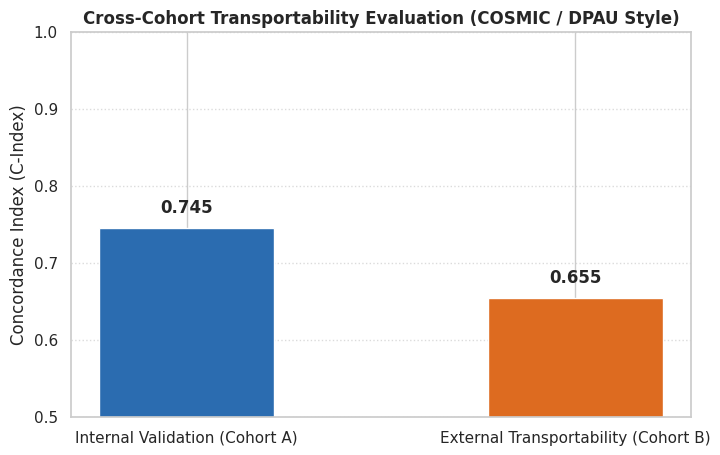

Internal C-Index (Cohort A): 0.745
External C-Index (Cohort B): 0.655


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# Install sksurv library if not already installed
!pip install sksurv

# 1. Prepare Features & Structured Targets
features = ['Age', 'Education_Yrs', 'APOE4', 'MMSE', 'Functional_Score']

X_train = df_cohort_A[features]
y_train = np.array(
    [(bool(s), t) for s, t in zip(df_cohort_A['Conversion_Status'], df_cohort_A['Followup_Months'])],
    dtype=[('Status', '?'), ('Time', '<f8')]
)

X_test_ext = df_cohort_B[features]
y_test_ext = np.array(
    [(bool(s), t) for s, t in zip(df_cohort_B['Conversion_Status'], df_cohort_B['Followup_Months'])],
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 2. Fit RSF on Cohort A
rsf_harmonized = RandomSurvivalForest(n_estimators=100, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1)
rsf_harmonized.fit(X_train, y_train)

# 3. Internal C-Index (Cohort A)
cindex_internal = rsf_harmonized.score(X_train, y_train)

# 4. External Validation C-Index (Cohort B Transportability)
cindex_external = rsf_harmonized.score(X_test_ext, y_test_ext)

# Visualizing Transportability Performance
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(['Internal Validation (Cohort A)', 'External Transportability (Cohort B)'],
               [cindex_internal, cindex_external],
               color=['#2b6cb0', '#dd6b20'], width=0.45)

plt.ylabel('Concordance Index (C-Index)')
plt.title('Cross-Cohort Transportability Evaluation (COSMIC / DPAU Style)', fontweight='bold')
plt.ylim(0.5, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

print(f"Internal C-Index (Cohort A): {cindex_internal:.3f}")
print(f"External C-Index (Cohort B): {cindex_external:.3f}")

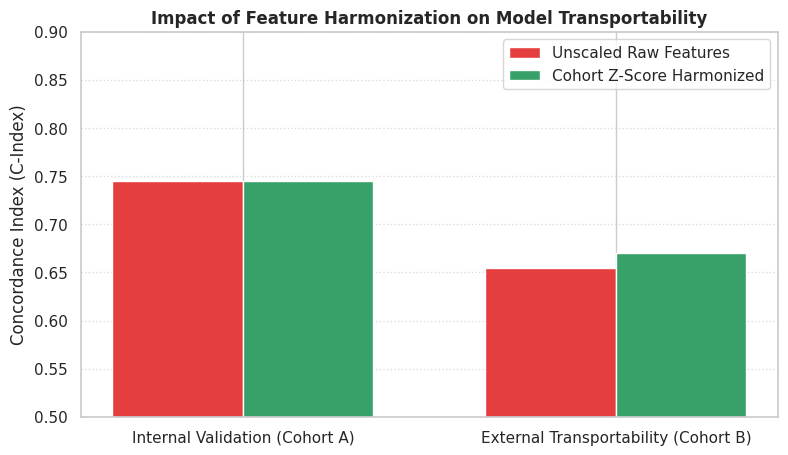

Harmonized External C-Index (Cohort B): 0.670 (Up from 0.655)


In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Standardize features independently within Cohort A and Cohort B
scaler_A = StandardScaler()
scaler_B = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler_A.fit_transform(df_cohort_A[features]),
    columns=features
)

X_test_ext_scaled = pd.DataFrame(
    scaler_B.fit_transform(df_cohort_B[features]),
    columns=features
)

# 2. Fit Random Survival Forest on Harmonized Cohort A
rsf_harmonized_scaled = RandomSurvivalForest(
    n_estimators=100, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1
)
rsf_harmonized_scaled.fit(X_train_scaled, y_train)

# 3. Evaluate Scaled Performances
cindex_internal_scaled = rsf_harmonized_scaled.score(X_train_scaled, y_train)
cindex_external_scaled = rsf_harmonized_scaled.score(X_test_ext_scaled, y_test_ext)

# 4. Plot Comparison Before vs. After Harmonization
plt.figure(figsize=(9, 5))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [cindex_internal, cindex_external], width, label='Unscaled Raw Features', color='#e53e3e')
plt.bar(x + width/2, [cindex_internal_scaled, cindex_external_scaled], width, label='Cohort Z-Score Harmonized', color='#38a169')

plt.ylabel('Concordance Index (C-Index)')
plt.title('Impact of Feature Harmonization on Model Transportability', fontweight='bold')
plt.xticks(x, ['Internal Validation (Cohort A)', 'External Transportability (Cohort B)'])
plt.ylim(0.5, 0.9)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

print(f"Harmonized External C-Index (Cohort B): {cindex_external_scaled:.3f} (Up from {cindex_external:.3f})")